<a href="https://colab.research.google.com/github/Sumitsharma12321/fake-news-cross-generalization/blob/main/EDA_and_Classical_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

MODEL_DIR = "/content/drive/MyDrive/FakeNews_Project/saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Model directory:", MODEL_DIR)

Model directory: /content/drive/MyDrive/FakeNews_Project/saved_models


# **Classical ML Tier — Fake News Cross-Generalization Study**

Tier 1: Logistic Regression / Linear SVM / Multinomial Naive Bayes

Research project: Cross-Generalization and Explainability Analysis of Fake News Detectors Under LLM-Generated Style Attacks

What this notebook does:

Trains three classical ML detectors on the human-written ISOT dataset only.
Evaluates them in-distribution (held-out human test set).
Saves the trained models + TF-IDF vectorizer so they can later be evaluated out-of-distribution on MegaFake, without any retraining.


# 1. **Imports**

We only need pandas/numpy for data handling, scikit-learn for modeling and
metrics, and matplotlib/seaborn for plots. Keeping the import list small
keeps the notebook easy to read and reproduce.


In [3]:
import re
import string
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV  # gives LinearSVC a predict_proba for ROC-AUC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


# **2. Configuration**



# Label convention (per project spec): REAL = 0, FAKE = 1.

In [4]:
# ----- Paths: change these to match where you place the ISOT CSVs -----
FAKE_CSV_PATH = "/content/Fake.csv"
TRUE_CSV_PATH = "/content/True.csv"

# ----- Reproducibility -----
RANDOM_STATE = 42

# ----- Label convention -----
LABEL_REAL = 0
LABEL_FAKE = 1

# ----- Split ratios (train / val / test) -----
TEST_SIZE = 0.15        # held out for final in-distribution test
VAL_SIZE = 0.15         # held out for model selection (validation)
# (remaining ~0.70 is training)

# ----- TF-IDF settings -----
TFIDF_MAX_FEATURES = 50_000
TFIDF_NGRAM_RANGE = (1, 2)   # unigrams + bigrams
TFIDF_MIN_DF = 2

# ----- Output paths for saved artifacts -----
MODEL_DIR = "/content/drive/MyDrive/FakeNews_Project/saved_models"   # <-- FIXED

import os
os.makedirs(MODEL_DIR, exist_ok=True)
print("Model directory:", MODEL_DIR)

Model directory: /content/drive/MyDrive/FakeNews_Project/saved_models


## **3. Load ISOT Dataset**

In [5]:
fake_df = pd.read_csv(FAKE_CSV_PATH)
true_df = pd.read_csv(TRUE_CSV_PATH)

print("Fake.csv shape:", fake_df.shape)
print("True.csv shape:", true_df.shape)



Fake.csv shape: (23481, 4)
True.csv shape: (21417, 4)


# **4. Inspect Dataset**
Quick sanity checks before any cleaning: column names, dtypes, a few sample
rows, and the subject/date distributions. This step exists to catch
surprises early (e.g. unexpected columns, encoding issues, or a subject
category that's wildly imbalanced) before they silently affect training.

In [6]:
print("Fake.csv columns:", list(fake_df.columns))
print("True.csv columns:", list(true_df.columns))

display(fake_df.head())
display(true_df.head())


Fake.csv columns: ['title', 'text', 'subject', 'date']
True.csv columns: ['title', 'text', 'subject', 'date']


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
print("\n--- Fake.csv info ---")
fake_df.info()
print("\n--- True.csv info ---")
true_df.info()



--- Fake.csv info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB

--- True.csv info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [8]:
print("Subject distribution (Fake):")
print(fake_df["subject"].value_counts())
print("\nSubject distribution (True):")
print(true_df["subject"].value_counts())

Subject distribution (Fake):
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

Subject distribution (True):
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64


In [9]:
# Date range check
print("\nDate range (Fake):", fake_df["date"].min(), "to", fake_df["date"].max())
print("Date range (True):", true_df["date"].min(), "to", true_df["date"].max())



Date range (Fake): 14-Feb-18 to https://fedup.wpengine.com/wp-content/uploads/2015/04/hillarystreetart.jpg
Date range (True): April 1, 2016  to September 9, 2017 


In [10]:
print(true_df["text"].iloc[0][:200])

WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal 


## 5. Clean and Combine Fake.csv and True.csv

### Steps:

1. **Assign labels:**  
   Assign `FAKE = 1` and `REAL = 0` according to the project's label convention.

2. **Combine title and text:**  
   Combine the `title` and `text` columns into a single `content` field.  
   This allows the model to use information from both the headline and the article body.

3. **Combine and shuffle the datasets:**  
   Concatenate `Fake.csv` and `True.csv` into a single dataframe and shuffle the data to avoid a long sequence of one class.

In [11]:
fake_df = fake_df.copy()
true_df = true_df.copy()

fake_df["label"] = LABEL_FAKE
true_df["label"] = LABEL_REAL

df = pd.concat([fake_df, true_df], axis=0, ignore_index=True)

# Combine title + text into one field used for modeling.
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")
df["content"] = (df["title"] + " " + df["text"]).str.strip()

# Shuffle so classes are interleaved (not strictly required for TF-IDF/sklearn,
# but good practice and makes any manual eyeballing of df.head() more honest).
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
df[["title", "content", "subject", "date", "label"]].head()


(44898, 6)


,title,content,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,Ben Stein Calls Out 9th Circuit Court: Committ...,US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,Trump drops Steve Bannon from National Securit...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,Puerto Rico expects U.S. to lift Jones Act shi...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,OOPS: Trump Just Accidentally Confirmed He Lea...,News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,Donald Trump heads for Scotland to reopen a go...,politicsNews,"June 24, 2016",0


# **6. Remove Duplicates and Missing Values**
rows with an empty content field after cleaning,
exact duplicate content rows (keeping the first occurrence).

In [12]:
before = len(df)

# Drop rows with missing/empty content.
df = df[df["content"].str.strip().str.len() > 0].copy()

# Drop exact duplicate articles.
df = df.drop_duplicates(subset="content", keep="first").copy()

after = len(df)
print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning:  {after}")
print(f"Rows removed:         {before - after}")

df["label"].value_counts()


Rows before cleaning: 44898
Rows after cleaning:  39103
Rows removed:         5795


,count
label,
0,21196
1,17907


### Light Text Preprocessing

We apply light text preprocessing to preserve the original writing style of the news articles.

The preprocessing includes:
- Converting text to lowercase.
- Removing URLs.
- Removing extra whitespace.

We do not manually remove stopwords, as TF-IDF will handle stopword removal during vectorization. We also do not apply stemming or lemmatization because preserving stylistic features is important for the LIME-based explainability analysis.

In [13]:
def light_clean(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # remove URLs
    text = re.sub(r"\s+", " ", text)                 # collapse whitespace
    return text.strip()

df["content_clean"] = df["content"].apply(light_clean)
df[["content", "content_clean"]].head(3)


,content,content_clean
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls out 9th circuit court: committ...
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon from national securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u.s. to lift jones act shi...


## **7. Exploratory Data Analysis (EDA)**

The purpose of EDA is to understand the class distribution and article length in the ISOT dataset.

We examine:
- The distribution of REAL and FAKE news articles.
- The proportion of each class.
- The distribution of article lengths.

Article length is also examined because it may act as a shortcut feature that classifiers can rely on instead of learning meaningful indicators of news veracity.

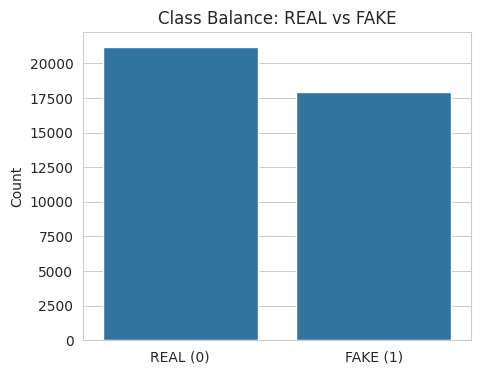

label
REAL    0.542056
FAKE    0.457944
Name: proportion, dtype: float64


In [14]:
plt.figure(figsize=(5, 4))
sns.countplot(x="label", data=df)
plt.xticks([0, 1], ["REAL (0)", "FAKE (1)"])
plt.title("Class Balance: REAL vs FAKE")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

print(df["label"].value_counts(normalize=True).rename({0: "REAL", 1: "FAKE"}))


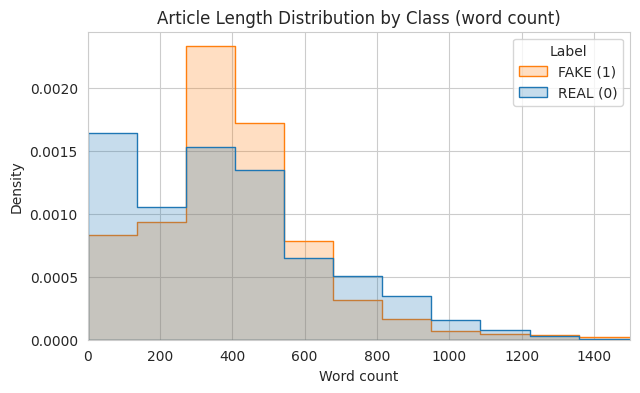

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,21196.0,394.827043,273.768906,4.0,157.75,368.5,533.0,5181.0
1,17907.0,428.773831,356.981188,0.0,279.00,385.0,514.0,8148.0


In [15]:
df["content_len"] = df["content_clean"].str.split().apply(len)

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="content_len", hue="label", bins=60, kde=False,
             element="step", stat="density", common_norm=False)
plt.xlim(0, 1500)
plt.title("Article Length Distribution by Class (word count)")
plt.xlabel("Word count")
plt.legend(title="Label", labels=["FAKE (1)", "REAL (0)"])
plt.show()

df.groupby("label")["content_len"].describe()


## **8. Stratified Train / Validation / Test Split**

The dataset is divided into training, validation, and test sets using a stratified split to preserve the REAL/FAKE class distribution.

- **Training set:** Used to train the models.
- **Validation set:** Used for model selection and hyperparameter tuning.
- **Test set:** Kept completely unseen until the final evaluation.

Stratification ensures that the proportion of REAL and FAKE news remains approximately consistent across all three sets.

In [16]:
X = df["content_clean"].values
y = df["label"].values

# First split off the test set.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Then split the remainder into train / validation.
val_ratio_of_temp = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio_of_temp,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print(f"Train: {len(X_train)}  ({len(X_train)/len(df):.1%})")
print(f"Val:   {len(X_val)}    ({len(X_val)/len(df):.1%})")
print(f"Test:  {len(X_test)}   ({len(X_test)/len(df):.1%})")

for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    ratio = np.mean(y_split)
    print(f"{name} FAKE ratio: {ratio:.3f}")



Train: 27371  (70.0%)
Val:   5866    (15.0%)
Test:  5866   (15.0%)
Train FAKE ratio: 0.458
Val FAKE ratio: 0.458
Test FAKE ratio: 0.458


## **9. TF-IDF Vectorization**

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert the cleaned news articles into numerical features that can be used by the classical machine learning models.

The TF-IDF vectorizer is fitted **only on the training data** to prevent data leakage. The validation and test data are transformed using the same fitted vectorizer.

The same TF-IDF representation is used for Logistic Regression, Linear SVM, and Multinomial Naive Bayes to ensure a fair comparison.

In [17]:
tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    stop_words="english",
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform on TRAIN ONLY
X_val_tfidf = tfidf.transform(X_val)           # transform only
X_test_tfidf = tfidf.transform(X_test)         # transform only

print("Vocabulary size:", len(tfidf.vocabulary_))
print("Train TF-IDF shape:", X_train_tfidf.shape)


Vocabulary size: 50000
Train TF-IDF shape: (27371, 50000)


## **10. Train Logistic Regression**

Logistic Regression is used as a strong and interpretable linear baseline for fake-news classification. The model is trained using the TF-IDF features extracted from the training data.

In [18]:
logreg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)
logreg.fit(X_train_tfidf, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


## **11. Train Linear SVM**

Linear SVM is suitable for high-dimensional and sparse text data. A calibrated version is used so that probability estimates can be obtained for evaluation metrics such as ROC-AUC.

In [19]:
base_svm = LinearSVC(random_state=RANDOM_STATE)
svm = CalibratedClassifierCV(base_svm, cv=5)
svm.fit(X_train_tfidf, y_train)
print("Linear SVM (calibrated) trained.")



Linear SVM (calibrated) trained.


## **12. Train Multinomial Naive Bayes**

Multinomial Naive Bayes is included as a fast and simple probabilistic baseline for text classification. Its performance provides a reference point for comparison with the other classical and deep-learning models.

In [20]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
print("Multinomial Naive Bayes trained.")



Multinomial Naive Bayes trained.


# **13. Evaluation Function + Human Test Set Evaluation**

In [21]:
def evaluate_model(model, X_tfidf, y_true, model_name, dataset_name):
    """Compute the standard metric set for one model on one dataset split.

    This exact function will be reused, unmodified, for MegaFake OOD
    evaluation later — that's the whole point of writing it once here.
    """
    y_pred = model.predict(X_tfidf)

    # predict_proba is used for ROC-AUC; all three of our models support it
    # (LogReg and MultinomialNB natively, LinearSVC via CalibratedClassifierCV).
    y_proba = model.predict_proba(X_tfidf)[:, 1]

    results = {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }
    return results, y_pred


In [22]:
models = {
    "Logistic Regression": logreg,
    "Linear SVM": svm,
    "Multinomial NB": nb,
}

# ---- Validation results: used ONLY to compare/select among models ----
val_results = []
for name, model in models.items():
    res, _ = evaluate_model(model, X_val_tfidf, y_val, name, "Human-Validation")
    val_results.append(res)

val_results_df = pd.DataFrame(val_results).sort_values("F1", ascending=False).reset_index(drop=True)
val_results_df


,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Linear SVM,Human-Validation,0.994715,0.995151,0.993299,0.994224,0.999323
1,Logistic Regression,Human-Validation,0.988749,0.993967,0.981385,0.987636,0.998367
2,Multinomial NB,Human-Validation,0.957893,0.952505,0.955696,0.954098,0.990263


In [23]:
# ---- Test results: the untouched, final, one-shot in-distribution score ----
test_results = []
test_preds = {}
for name, model in models.items():
    res, y_pred = evaluate_model(model, X_test_tfidf, y_test, name, "Human-ID")
    test_results.append(res)
    test_preds[name] = y_pred

human_id_results_df = pd.DataFrame(test_results).sort_values("F1", ascending=False).reset_index(drop=True)
human_id_results_df


,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Linear SVM,Human-ID,0.994033,0.996256,0.990692,0.993466,0.999586
1,Logistic Regression,Human-ID,0.984828,0.992416,0.974311,0.983280,0.998533
2,Multinomial NB,Human-ID,0.952949,0.947290,0.950112,0.948699,0.988591


## **14. Confusion Matrices (Human Test Set)**

Confusion matrices are used to examine the types of classification errors made by each model on the human-written test set.

They show the number of:
- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

This provides a more detailed view of model performance beyond accuracy and F1-score.

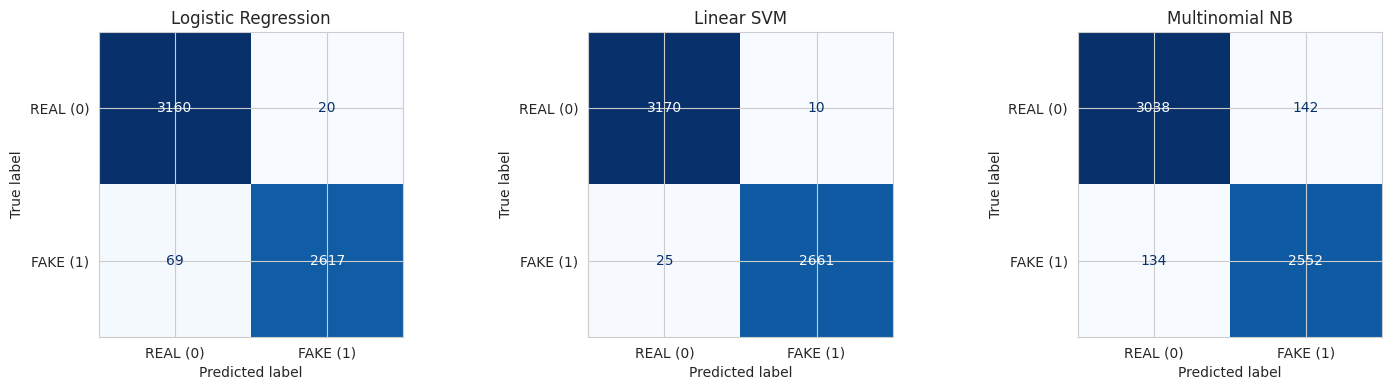

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, test_preds[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["REAL (0)", "FAKE (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.show()



## **15. Model Comparison Table (Human-ID)**

The validation and Human-ID test results are presented using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Model selection is based **only on validation F1-score**. The Human-ID test set is not used for model selection.

The selected model will later be evaluated on the MegaFake-OOD dataset without retraining.

In [25]:
print("=== Validation set (for model selection only) ===")
display(val_results_df)

print("\n=== Human-ID Test set (final, untouched, in-distribution) ===")
display(human_id_results_df)

# Best model by validation F1 — selection is based on validation, not test/OOD.
best_model_name = val_results_df.iloc[0]["Model"]
print(f"\nBest model by validation F1: {best_model_name}")



=== Validation set (for model selection only) ===


,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Linear SVM,Human-Validation,0.994715,0.995151,0.993299,0.994224,0.999323
1,Logistic Regression,Human-Validation,0.988749,0.993967,0.981385,0.987636,0.998367
2,Multinomial NB,Human-Validation,0.957893,0.952505,0.955696,0.954098,0.990263



=== Human-ID Test set (final, untouched, in-distribution) ===


,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Linear SVM,Human-ID,0.994033,0.996256,0.990692,0.993466,0.999586
1,Logistic Regression,Human-ID,0.984828,0.992416,0.974311,0.983280,0.998533
2,Multinomial NB,Human-ID,0.952949,0.947290,0.950112,0.948699,0.988591



Best model by validation F1: Linear SVM


# **16. Save Trained Models and TF-IDF Vectorizer**

In [26]:
joblib.dump(tfidf, f"{MODEL_DIR}/tfidf_vectorizer.joblib")
joblib.dump(logreg, f"{MODEL_DIR}/logistic_regression.joblib")
joblib.dump(svm, f"{MODEL_DIR}/linear_svm_calibrated.joblib")
joblib.dump(nb, f"{MODEL_DIR}/multinomial_nb.joblib")

# Also persist the Human-ID results table itself, so it can be concatenated
# with the future MegaFake-OOD table without re-running this whole notebook.
human_id_results_df.to_csv(f"{MODEL_DIR}/human_id_results.csv", index=False)

print("Saved to:", MODEL_DIR)
print(os.listdir(MODEL_DIR))



Saved to: /content/drive/MyDrive/FakeNews_Project/saved_models
['.ipynb_checkpoints', 'tfidf_vectorizer.joblib', 'logistic_regression.joblib', 'linear_svm_calibrated.joblib', 'multinomial_nb.joblib', 'human_id_results.csv']


In [27]:
# Save validation metrics
val_results_df.to_csv(
    f"{MODEL_DIR}/validation_results.csv",
    index=False
)


# **17. Reusable Evaluation Function for Future MegaFake OOD Testing**

In [28]:
# ============================================================
# SECTION 17 (FIXED): Reusable Evaluation Function — MegaFake OOD Testing
# ============================================================

import os
import re
import json
import numpy as np
import pandas as pd



DRIVE_ROOT = "/content/drive/MyDrive"

# we only take political news
TARGET_FOLDER_NAME = "69ajd-osfstorage-llama3_polifact-archive"
FAKE_FILENAME  = "megafake-1_style_based_fake.json"
LEGIT_FILENAME = "megafake-5_style_based_legitimate.json"

def find_file_in_named_folder(filename, folder_name, root=DRIVE_ROOT):
    matches = []
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath) == folder_name and filename in filenames:
            matches.append(os.path.join(dirpath, filename))
    if not matches:
        raise FileNotFoundError(
            f"Could not find '{filename}' inside a folder named '{folder_name}' under {root}"
        )
    if len(matches) > 1:
        print(f"WARNING: multiple matches found, using first: {matches}")
    return matches[0]

FAKE_JSON_PATH  = find_file_in_named_folder(FAKE_FILENAME, TARGET_FOLDER_NAME)
LEGIT_JSON_PATH = find_file_in_named_folder(LEGIT_FILENAME, TARGET_FOLDER_NAME)

print("Fake file :", FAKE_JSON_PATH)
print("Legit file:", LEGIT_JSON_PATH)



Fake file : /content/drive/MyDrive/MegaFake Dataset/69ajd-osfstorage-llama3_polifact-archive/megafake-1_style_based_fake.json
Legit file: /content/drive/MyDrive/MegaFake Dataset/69ajd-osfstorage-llama3_polifact-archive/megafake-5_style_based_legitimate.json


In [29]:

def normalize_entry(entry):
    """Returns the inner record dict regardless of flat/wrapped schema."""
    if isinstance(entry, dict):
        # Wrapped case: single key whose value is itself a dict
        if len(entry) >= 1 and all(isinstance(v, dict) for v in entry.values()):
            # could be wrapped with one or more nested dict values;
            # just take the first one that has a generated_text-like field
            for v in entry.values():
                if isinstance(v, dict):
                    return v
        # Flat case: entry itself is the record
        return entry
    return None

def extract_text_and_label(record, forced_label):
    """Pulls the LLM-generated text out of a normalized record."""
    text = record.get("generated_text")
    if not text:
        # some variants store it under generated_text_t01, t015 etc.
        for k, v in record.items():
            if k.startswith("generated_text") and v:
                text = v
                break
    return text, forced_label

def parse_megafake_json(filepath, forced_label):
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    records = []
    for entry in data:
        record = normalize_entry(entry)
        if record is None:
            continue
        text, label = extract_text_and_label(record, forced_label)
        if text:
            records.append({"text": text, "label": label})
    return records

fake_records  = parse_megafake_json(FAKE_JSON_PATH,  forced_label=1)
legit_records = parse_megafake_json(LEGIT_JSON_PATH, forced_label=0)

print(f"Fake records parsed : {len(fake_records)}")
print(f"Legit records parsed: {len(legit_records)}")





Fake records parsed : 7001
Legit records parsed: 2445


In [30]:
# ---- Sanity check before proceeding — confirm both are non-zero and topically consistent ----
print("\n---- FAKE samples ----")
for r in fake_records[:3]:
    print(r["text"][:150], "\n")

print("---- LEGIT samples ----")
for r in legit_records[:3]:
    print(r["text"][:150], "\n")

assert len(fake_records) > 0, "FAKE parsing still empty — check schema manually"
assert len(legit_records) > 0, "LEGIT parsing still empty — check schema manually"



---- FAKE samples ----
Disneyland Reopening Plan Sparks Misinformation About Scream-Free Rides

A recent social media post claiming that Disneyland in California has impleme 

**A Scathing Reality: Virginia's Teachers are Paid a Meager $52,466, a Disgraceful 28% Less than the Average Citizen**

The harsh truth about Virginia 

The American Rescue Plan, a $1.9 trillion COVID-19 relief package, has been subject to various misconceptions regarding its provisions. A recent Faceb 

---- LEGIT samples ----
Here's the polished version of the news article:

Virginia Democratic gubernatorial candidate Terry McAuliffe recently stated that the state ranks las 

Here's the polished news article:

Wisconsin Republicans Remain Skeptical of Marijuana Legalization

The legalization of marijuana remains a contentio 

Georgia Bill Would Restrict Voting Access, Ban Food and Water Giveaways to Voters

Georgia lawmakers have proposed several measures to overhaul the st 



In [32]:

BOILERPLATE_PATTERNS = [
    r"^here'?s (the|an) (polished|adjusted|modified|revised|updated) version.*?:\s*",
    r"^the following is a (polished|revised|adjusted) version.*?:\s*",
    r"^i have (revised|rewritten|polished).*?:\s*",
    r"^an adjusted version of this article.*?:\s*",
]

def strip_llm_preamble(text):
    for pattern in BOILERPLATE_PATTERNS:
        text = re.sub(pattern, "", text, flags=re.IGNORECASE | re.DOTALL)
    return text.strip()

for r in fake_records:
    r["text"] = strip_llm_preamble(r["text"])
for r in legit_records:
    r["text"] = strip_llm_preamble(r["text"])



In [33]:

# Stratified sampling

SAMPLE_SIZE_PER_CLASS = 750
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

def sample_records(records, n, rng):
    if len(records) <= n:
        return records
    idx = rng.choice(len(records), size=n, replace=False)
    return [records[i] for i in idx]

fake_sample  = sample_records(fake_records,  SAMPLE_SIZE_PER_CLASS, rng)
legit_sample = sample_records(legit_records, SAMPLE_SIZE_PER_CLASS, rng)

ood_df = pd.DataFrame(fake_sample + legit_sample)
ood_df = ood_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("\nFinal OOD set shape:", ood_df.shape)
print(ood_df["label"].value_counts())


Final OOD set shape: (1500, 2)
label
0    750
1    750
Name: count, dtype: int64


In [34]:

# Clean text using the SAME cleaning function as ISOT training data

ood_df["text"] = ood_df["text"].fillna("")
ood_df["content_clean"] = ood_df["text"].apply(light_clean)

def load_megafake():
    X_ood = ood_df["content_clean"].values
    y_ood = ood_df["label"].values
    return X_ood, y_ood

In [35]:

# Evaluation + generalization gap — UNCHANGED

def evaluate_all_models_on_ood(models_dict, tfidf_vectorizer, X_ood, y_ood, dataset_name="MegaFake-OOD"):
    X_ood_tfidf = tfidf_vectorizer.transform(X_ood)
    ood_results = []
    for name, model in models_dict.items():
        res, _ = evaluate_model(model, X_ood_tfidf, y_ood, name, dataset_name)
        ood_results.append(res)
    return pd.DataFrame(ood_results)

def generalization_gap(human_id_df, ood_df_results, metric="F1"):
    merged = human_id_df[["Model", metric]].merge(
        ood_df_results[["Model", metric]], on="Model", suffixes=("_Human-ID", "_OOD")
    )
    merged["Generalization_Gap"] = merged[f"{metric}_Human-ID"] - merged[f"{metric}_OOD"]
    return merged

In [36]:
  # ------------------------------------------------------------
# Run

loaded_tfidf = joblib.load(f"{MODEL_DIR}/tfidf_vectorizer.joblib")
loaded_models = {
    "Logistic Regression": joblib.load(f"{MODEL_DIR}/logistic_regression.joblib"),
    "Linear SVM": joblib.load(f"{MODEL_DIR}/linear_svm_calibrated.joblib"),
    "Multinomial NB": joblib.load(f"{MODEL_DIR}/multinomial_nb.joblib"),
}

X_ood, y_ood = load_megafake()
megafake_results_df = evaluate_all_models_on_ood(loaded_models, loaded_tfidf, X_ood, y_ood)

full_comparison_df = pd.concat([human_id_results_df, megafake_results_df], ignore_index=True)
gap_df = generalization_gap(human_id_results_df, megafake_results_df)

display(full_comparison_df)
display(gap_df)

,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Linear SVM,Human-ID,0.994033,0.996256,0.990692,0.993466,0.999586
1,Logistic Regression,Human-ID,0.984828,0.992416,0.974311,0.983280,0.998533
2,Multinomial NB,Human-ID,0.952949,0.947290,0.950112,0.948699,0.988591
3,Logistic Regression,MegaFake-OOD,0.568667,0.545697,0.820000,0.655301,0.671586
4,Linear SVM,MegaFake-OOD,0.525333,0.513889,0.937333,0.663834,0.657426
5,Multinomial NB,MegaFake-OOD,0.614000,0.609195,0.636000,0.622309,0.661243


,Model,F1_Human-ID,F1_OOD,Generalization_Gap
0,Linear SVM,0.993466,0.663834,0.329633
1,Logistic Regression,0.983280,0.655301,0.327979
2,Multinomial NB,0.948699,0.622309,0.326390


In [39]:
full_comparison_df.to_csv(f"{MODEL_DIR}/full_comparison_results.csv", index=False)
gap_df.to_csv(f"{MODEL_DIR}/generalization_gap.csv", index=False)

print(os.listdir(MODEL_DIR))

['.ipynb_checkpoints', 'tfidf_vectorizer.joblib', 'logistic_regression.joblib', 'linear_svm_calibrated.joblib', 'multinomial_nb.joblib', 'human_id_results.csv', 'validation_results.csv', 'full_comparison_results.csv', 'generalization_gap.csv']


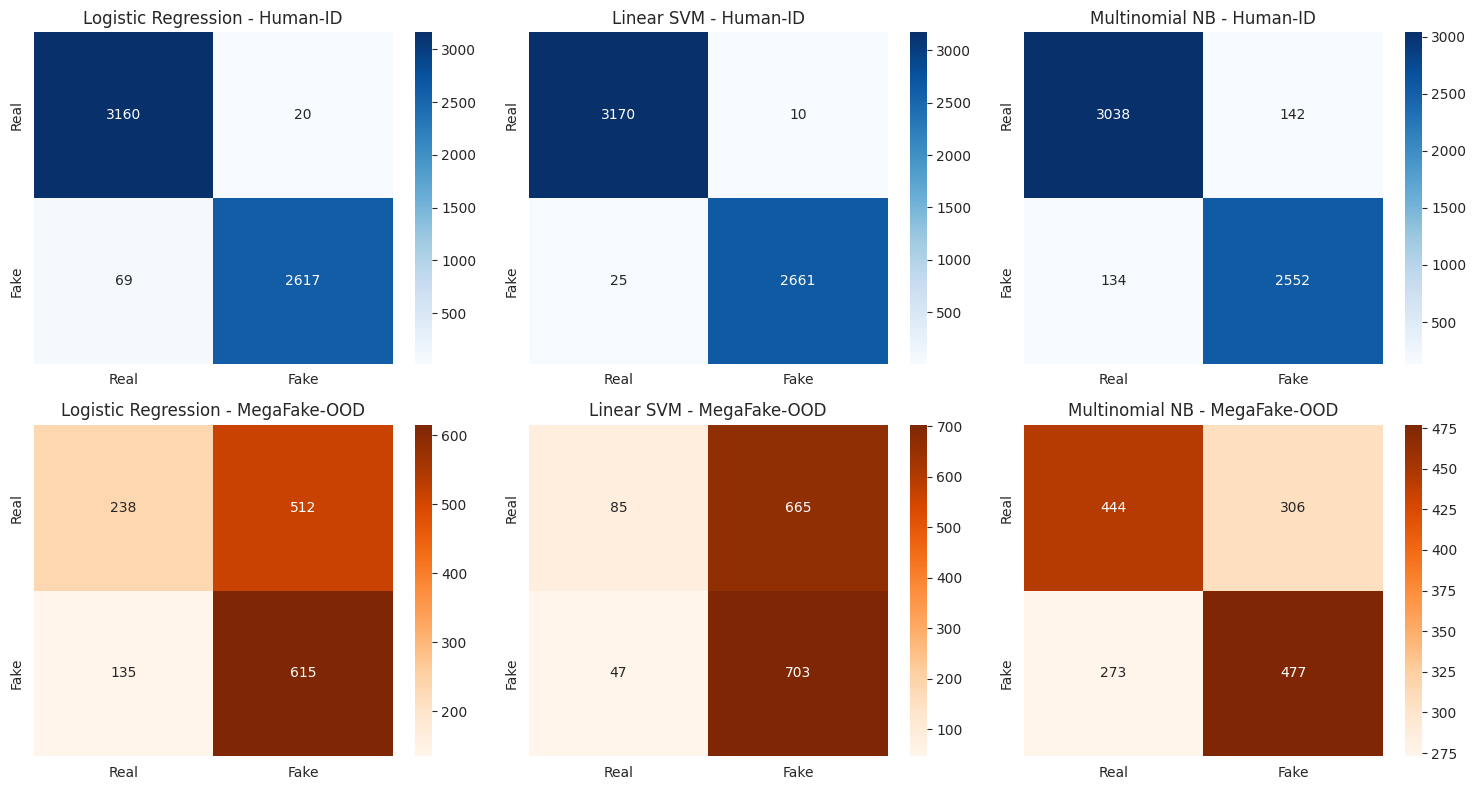

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

X_ood_tfidf = loaded_tfidf.transform(ood_df["content_clean"].values)
y_ood = ood_df["label"].values

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (name, model) in enumerate(loaded_models.items()):
    y_pred_human = model.predict(X_test_tfidf)
    cm_human = confusion_matrix(y_test, y_pred_human)
    sns.heatmap(cm_human, annot=True, fmt="d", cmap="Blues", ax=axes[0, i],
                xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
    axes[0, i].set_title(f"{name} - Human-ID")

    y_pred_ood = model.predict(X_ood_tfidf)
    cm_ood = confusion_matrix(y_ood, y_pred_ood)
    sns.heatmap(cm_ood, annot=True, fmt="d", cmap="Oranges", ax=axes[1, i],
                xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
    axes[1, i].set_title(f"{name} - MegaFake-OOD")

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/confusion_matrices.png", dpi=150)
plt.show()

In [48]:
import pandas as pd
import os

SPLITS_DIR = f"{MODEL_DIR}/../splits"
os.makedirs(SPLITS_DIR, exist_ok=True)

train_df = pd.DataFrame({"text": X_train, "label": y_train})
val_df   = pd.DataFrame({"text": X_val,   "label": y_val})
test_df  = pd.DataFrame({"text": X_test,  "label": y_test})

train_df.to_csv(f"{SPLITS_DIR}/train.csv", index=False)
val_df.to_csv(f"{SPLITS_DIR}/val.csv", index=False)
test_df.to_csv(f"{SPLITS_DIR}/test.csv", index=False)

print("Saved splits to:", SPLITS_DIR)
print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)

Saved splits to: /content/drive/MyDrive/FakeNews_Project/saved_models/../splits
Train: (27371, 2) Val: (5866, 2) Test: (5866, 2)


In [49]:
ood_df.to_csv(f"{SPLITS_DIR}/megafake_ood_test.csv", index=False)
print("Saved OOD test set to:", SPLITS_DIR)

Saved OOD test set to: /content/drive/MyDrive/FakeNews_Project/saved_models/../splits
